In [13]:
#  IMPORTS AND CONFIGURATION
# Importing all necessary libraries

import pandas as pd
import numpy as np
import re
import nltk
import urllib.request
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score, roc_curve
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# Initialize stemmer and stop words
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

print("All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
# Remove the sklearn line or add: import sklearn
print("All imports complete!")

All libraries imported successfully!
Pandas version: 2.2.3
NumPy version: 1.26.4
All imports complete!


In [ ]:
# DOWNLOAD AND PREPROCESS DATA
# it will save cleaned data for all models

print("="*70)
print("STEP 1: DOWNLOADING AND PREPROCESSING DATA")
print("="*70)

def download_sentiment140():
    """Download Sentiment140 dataset"""
    print("\n Downloading Sentiment140 dataset...")
    
    url = "https://mmlspark.blob.core.windows.net/publicwasb/twittersentimenttrainingandtestdata.zip"
    zip_path = "sentiment140.zip"
    
    try:
        urllib.request.urlretrieve(url, zip_path)
        print(" Download complete!")
    except:
        print("Download failed, using alternative source...")
        url = "https://raw.githubusercontent.com/kazanova/sentiment140/master/data/training.1600000.processed.noemoticon.csv"
        return pd.read_csv(url, encoding='latin-1', names=['target', 'id', 'date', 'flag', 'user', 'text'])
    
    print("Extracting files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    
    csv_file = "training.1600000.processed.noemoticon.csv"
    df = pd.read_csv(csv_file, encoding='latin-1', names=['target', 'id', 'date', 'flag', 'user', 'text'])
    
    # Cleanup
    os.remove(zip_path)
    os.remove(csv_file)
    
    return df

def clean_text(text):
    """Clean and preprocess tweet text"""
    if not isinstance(text, str):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove user mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags (keep the word)
    text = re.sub(r'#(\w+)', r'\1', text)
    
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove stopwords and stem
    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stop_words]
    
    return ' '.join(words)

# Load data
print("\n📊 Loading dataset...")
df = download_sentiment140()
print(f" Loaded {len(df):,} tweets")

# Remove neutral tweets (polarity=2) for binary classification
df = df[df['target'] != 2]
df['target'] = df['target'].replace(4, 1)  # Convert 4 to 1 for positive
print(f" After removing neutral: {len(df):,} tweets")
print(f"  Positive: {(df['target']==1).sum():,}")
print(f"  Negative: {(df['target']==0).sum():,}")

# Clean text
print("\n Cleaning text data...")
df['cleaned_text'] = df['text'].apply(clean_text)

# Remove empty texts
df = df[df['cleaned_text'].str.len() > 0]
print(f" After cleaning: {len(df):,} tweets")

# Save cleaned data for reuse
df[['cleaned_text', 'target']].to_csv('sentiment140_cleaned.csv', index=False)
print("\n Cleaned data saved to 'sentiment140_cleaned.csv'")

print("\n Data preprocessing complete!")

STEP 1: DOWNLOADING AND PREPROCESSING DATA

📊 Loading dataset...

 Download complete!
Extracting files...
 Loaded 1,600,000 tweets
 After removing neutral: 1,600,000 tweets
  Positive: 800,000
  Negative: 800,000

 Cleaning text data...


# EXPLORATORY DATA ANALYSIS
Exploratory Data Analysis (EDA) is the process of examining and summarizing a dataset to understand its main characteristics before applying any formal modeling or advanced analysis. It involves using statistical methods and visual techniques to explore the structure of the data, identify patterns, detect anomalies or outliers, and check assumptions such as distribution or relationships between variables. EDA helps data analysts and scientists gain insights into the data, clean it if necessary, and decide which methods or models are most suitable for further analysis

In [ ]:
# Understand your data

print("="*70)
print("STEP 2: EXPLORATORY DATA ANALYSIS")
print("="*70)

# Load cleaned data (if you skipped Cell 2)
if 'df' not in locals():
    df = pd.read_csv('sentiment140_cleaned.csv')

# Class distribution
print("\n Class Distribution:")
print(f"Positive tweets: {(df['target']==1).sum():,} ({(df['target']==1).mean()*100:.1f}%)")
print(f"Negative tweets: {(df['target']==0).sum():,} ({(df['target']==0).mean()*100:.1f}%)")

# Text length analysis
df['text_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))
df['char_length'] = df['cleaned_text'].apply(len)

print(f"\n Text Statistics:")
print(f"Average words per tweet: {df['text_length'].mean():.2f}")
print(f"Max words: {df['text_length'].max()}")
print(f"Min words: {df['text_length'].min()}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Class distribution
axes[0,0].bar(['Negative', 'Positive'], df['target'].value_counts().values, color=['red', 'green'])
axes[0,0].set_title('Sentiment Distribution')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(df['target'].value_counts().values):
    axes[0,0].text(i, v + 1000, f'{v:,}', ha='center')

# 2. Word count distribution by sentiment
axes[0,1].hist([df[df['target']==0]['text_length'], df[df['target']==1]['text_length']], 
               label=['Negative', 'Positive'], bins=30, alpha=0.7, color=['red', 'green'])
axes[0,1].set_xlabel('Number of Words')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Tweet Length Distribution')
axes[0,1].legend()

# 3. Character length distribution
axes[1,0].hist([df[df['target']==0]['char_length'], df[df['target']==1]['char_length']], 
               label=['Negative', 'Positive'], bins=30, alpha=0.7, color=['red', 'green'])
axes[1,0].set_xlabel('Number of Characters')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Character Length Distribution')
axes[1,0].legend()

# 4. Top words for each sentiment
def get_top_words(df, sentiment, n=10):
    texts = df[df['target']==sentiment]['cleaned_text'].tolist()
    all_words = ' '.join(texts).split()
    return Counter(all_words).most_common(n)

top_pos = get_top_words(df, 1, 10)
top_neg = get_top_words(df, 0, 10)

axes[1,1].axis('off')
axes[1,1].text(0.1, 0.8, "Top Positive Words:", fontsize=12, fontweight='bold', color='green')
axes[1,1].text(0.1, 0.7, ", ".join([w for w, _ in top_pos[:5]]), fontsize=10)
axes[1,1].text(0.1, 0.5, "Top Negative Words:", fontsize=12, fontweight='bold', color='red')
axes[1,1].text(0.1, 0.4, ", ".join([w for w, _ in top_neg[:5]]), fontsize=10)
axes[1,1].set_title('Most Common Words')

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=100)
plt.show()

print("\n EDA complete! Visualizations saved as 'eda_visualizations.png'")

In [ ]:
# TRAIN-TEST SPLIT
# Prepares data for all models

print("="*70)
print("STEP 3: TRAIN-TEST SPLIT")
print("="*70)

# Prepare features and labels
X = df['cleaned_text'].values
y = df['target'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Data Split Complete:")
print(f"Training set: {len(X_train):,} samples")
print(f"  - Positive: {(y_train==1).sum():,}")
print(f"  - Negative: {(y_train==0).sum():,}")
print(f"\nTest set: {len(X_test):,} samples")
print(f"  - Positive: {(y_test==1).sum():,}")
print(f"  - Negative: {(y_test==0).sum():,}")

# Save splits for reuse (optional)
np.save('X_train.npy', X_train)
np.save('X_test.npy', X_test)
np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)

print("\n Data splits saved!")

#  BASELINE MODEL

In [ ]:
# Establish baseline

print("="*70)
print("STEP 4: BASELINE MODEL (Majority Class)")
print("="*70)

# Majority class baseline
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

print(f"\n Baseline Results:")
print(f"Accuracy: {baseline_accuracy:.4f}")
print(f"F1 Score: {baseline_f1:.4f}")
print(f"\n Baseline is just predicting majority class every time")

# LOGISTIC REGRESSION WITH TUNING
Logistic regression is a supervised machine learning algorithm used for binary classification that predicts the probability of an outcome using the sigmoid function applied to a linear model.

In [ ]:
print("="*70)
print("STEP 5: LOGISTIC REGRESSION WITH HYPERPARAMETER TUNING")
print("="*70)

# Define parameter grid
param_grid_lr = {
    'tfidf__max_features': [10000, 20000, 30000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.1, 1.0, 10.0],
    'clf__solver': ['lbfgs', 'saga']
}

# Create pipeline
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', sublinear_tf=True)),
    ('clf', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

# Grid search with cross-validation
print("\n🔍 Performing hyperparameter tuning...")
grid_lr = GridSearchCV(
    lr_pipeline, param_grid_lr, 
    cv=3, scoring='f1', 
    n_jobs=-1, verbose=1
)

# Use subset for faster tuning (30% of training data)
X_train_subset, _, y_train_subset, _ = train_test_split(
    X_train, y_train, train_size=0.3, random_state=42, stratify=y_train
)

grid_lr.fit(X_train_subset, y_train_subset)

print(f"\n Best parameters: {grid_lr.best_params_}")
print(f" Best CV F1 score: {grid_lr.best_score_:.4f}")

# Train best model on full training data
print("\n Training best model on full training data...")
best_lr = grid_lr.best_estimator_
best_lr.fit(X_train, y_train)

# Evaluate
y_pred_lr = best_lr.predict(X_test)
y_proba_lr = best_lr.predict_proba(X_test)[:, 1]

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_proba_lr)

print(f"\n Logistic Regression Results:")
print(f"Accuracy: {lr_accuracy:.4f}")
print(f"F1 Score: {lr_f1:.4f}")
print(f"ROC-AUC: {lr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Negative', 'Positive']))

# Save model
joblib.dump(best_lr, 'logistic_regression_model.pkl')
print("\n Model saved as 'logistic_regression_model.pkl'")

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# NAIVE BAYES WITH HYPERPARAMETER TUNING
Naive Bayes is a supervised machine learning algorithm based on Bayes' theorem, used for classification tasks, which assumes that features are independent of each other.

STEP 6: NAIVE BAYES WITH HYPERPARAMETER TUNING

🔍 Performing hyperparameter tuning...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

✅ Best parameters: {'clf__alpha': 2.0, 'vectorizer__max_features': 30000, 'vectorizer__ngram_range': (1, 2)}
✅ Best CV F1 score: 0.7593

🏋️ Training best model on full training data...

📊 Naive Bayes Results:
Accuracy: 0.7654
F1 Score: 0.7648
ROC-AUC: 0.8377

Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.77      0.77    159261
    Positive       0.77      0.76      0.76    159197

    accuracy                           0.77    318458
   macro avg       0.77      0.77      0.77    318458
weighted avg       0.77      0.77      0.77    318458


💾 Model saved as 'naive_bayes_model.pkl'


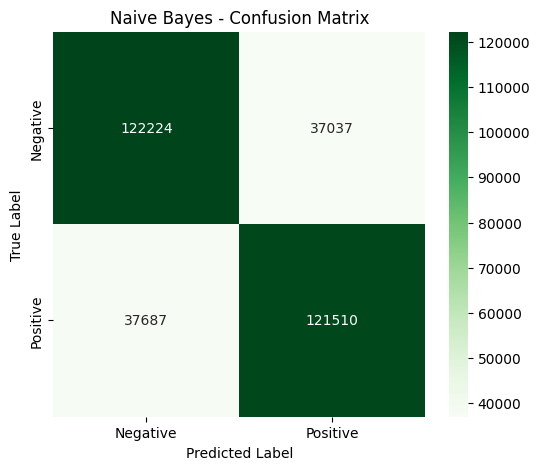

In [8]:
# Naive Bayes
print("="*70)
print("STEP 6: NAIVE BAYES WITH HYPERPARAMETER TUNING")
print("="*70)

# Define parameter grid
param_grid_nb = {
    'vectorizer__max_features': [10000, 20000, 30000],
    'vectorizer__ngram_range': [(1, 1), (1, 2)],
    'clf__alpha': [0.1, 0.5, 1.0, 2.0]
}

# Create pipeline (using CountVectorizer for Naive Bayes)
nb_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(stop_words='english')),
    ('clf', MultinomialNB())
])

# Grid search with cross-validation
print("\n Performing hyperparameter tuning...")
grid_nb = GridSearchCV(
    nb_pipeline, param_grid_nb, 
    cv=3, scoring='f1', 
    n_jobs=-1, verbose=1
)

# Use subset for faster tuning
X_train_subset, _, y_train_subset, _ = train_test_split(
    X_train, y_train, train_size=0.3, random_state=42, stratify=y_train
)

grid_nb.fit(X_train_subset, y_train_subset)

print(f"\n Best parameters: {grid_nb.best_params_}")
print(f" Best CV F1 score: {grid_nb.best_score_:.4f}")

# Train best model on full training data
print("\n Training best model on full training data...")
best_nb = grid_nb.best_estimator_
best_nb.fit(X_train, y_train)

# Evaluate
y_pred_nb = best_nb.predict(X_test)
y_proba_nb = best_nb.predict_proba(X_test)[:, 1]

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)
nb_auc = roc_auc_score(y_test, y_proba_nb)

print(f"\n Naive Bayes Results:")
print(f"Accuracy: {nb_accuracy:.4f}")
print(f"F1 Score: {nb_f1:.4f}")
print(f"ROC-AUC: {nb_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['Negative', 'Positive']))

# Save model
joblib.dump(best_nb, 'naive_bayes_model.pkl')
print("\n Model saved as 'naive_bayes_model.pkl'")

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Naive Bayes - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Deep Learning Model - LSTM for Sentiment Analysis
LSTM (Long Short-Term Memory) is a type of recurrent neural network (RNN) designed to learn long-term dependencies in sequential data by using memory cells and gates.

[nltk_data] Downloading package stopwords to C:\Users\Adnan
[nltk_data]     Saifi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



SENTIMENT ANALYSIS WITH LSTM (FIXED VERSION)
DOWNLOADING SENTIMENT140 DATASET

This may take a few minutes (dataset is ~80MB compressed)...
✓ Download complete!

Extracting files...
✓ Extraction complete!

Loading CSV file...

✓ Dataset loaded successfully!
  Total samples: 1,600,000
  Positive tweets: 800,000
  Negative tweets: 800,000

Using subset of 100,000 samples for faster training

Cleaning text data...
Tokenizing text...
Padding sequences...
✓ Preprocessing complete!
  Vocabulary size: 20000
  Sequence shape: (100000, 100)

✓ Data split complete!
  Training samples: 80,000
  Test samples: 20,000
  Input shape: 100 time steps

BUILDING LSTM MODEL (FIXED - WITH INPUT LAYER)

MODEL SUMMARY - SHOULD SHOW NO '?' OR '0 PARAMS'


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 100, 100)            │       2,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 100, 256)            │         234,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 128)                 │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,407,169 (9.18 MB)

 Trainable params: 2,407,169 (9.18 MB)

 Non-trainable params: 0 (0.00 B)


TRAINING MODEL
Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - accuracy: 0.5831 - loss: 0.6510 - val_accuracy: 0.7529 - val_loss: 0.5080 - learning_rate: 0.0010
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 270s 2s/step - accuracy: 0.7904 - loss: 0.4637 - val_accuracy: 0.7577 - val_loss: 0.5095 - learning_rate: 0.0010
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8241 - loss: 0.4058
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
125/125 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step - accuracy: 0.8241 - loss: 0.4058 - val_accuracy: 0.7576 - val_loss: 0.5217 - learning_rate: 0.0010
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - accuracy: 0.8503 - loss: 0.3605 - val_accuracy: 0.7529 - val_loss: 0.5477 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

EVALUATING MODEL
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 130ms/step

✓ Test Accuracy: 0.7541

Classification Report:
              precision 

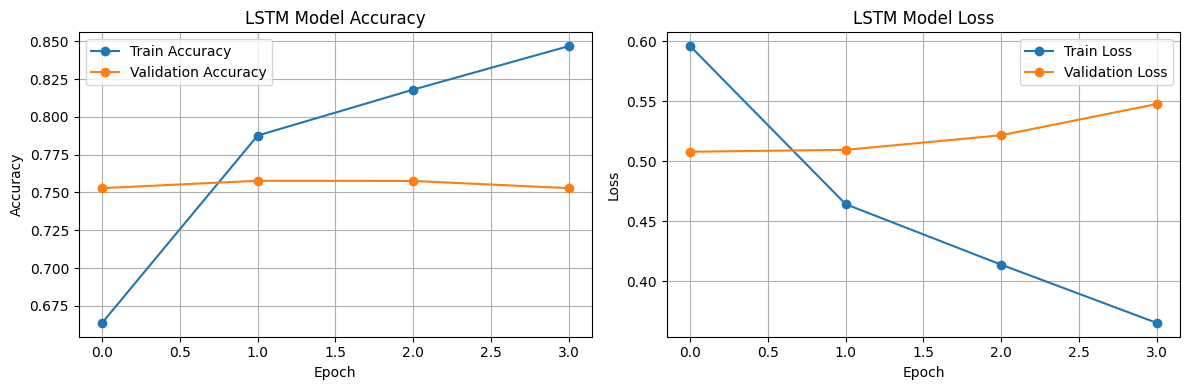

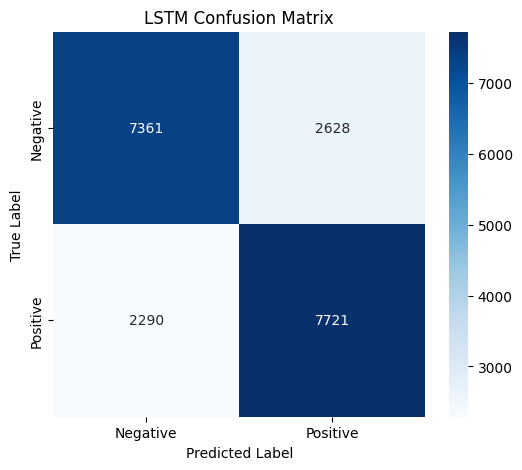


✓ Model saved as 'sentiment_lstm_model.h5'

TESTING WITH SAMPLE TWEETS

Tweet: I absolutely love this movie! Best film ever! 
Sentiment: Positive (confidence: 0.946)

Tweet: This product is terrible. Complete waste of money.
Sentiment: Negative (confidence: 0.799)

Tweet: The weather is okay today, nothing special.
Sentiment: Positive (confidence: 0.528)

Tweet: So happy with the amazing customer service! They're fantastic!
Sentiment: Positive (confidence: 0.944)

Tweet: What a disappointment. Worst experience of my life.
Sentiment: Negative (confidence: 0.772)

FINAL RESULTS FOR REPORT
LSTM Test Accuracy: 0.7541 (75.41%)
F1 Score: 0.7540

COMPLETED SUCCESSFULLY!


In [2]:

import pandas as pd
import numpy as np
import re
import nltk
import urllib.request
import zipfile
import os
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns

# Download stopwords if needed
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# ============================================
# 1. DOWNLOAD AND LOAD DATASET ONLINE
# ============================================

def download_sentiment140():
    """
    Download Sentiment140 dataset from Microsoft's official source
    """
    print("="*60)
    print("DOWNLOADING SENTIMENT140 DATASET")
    print("="*60)
    
    # URL from Microsoft's official Azure blob storage
    url = "https://mmlspark.blob.core.windows.net/publicwasb/twittersentimenttrainingandtestdata.zip"
    zip_path = "sentiment140.zip"
    
    print(f"\nDownloading from: {url}")
    print("This may take a few minutes (dataset is ~80MB compressed)...")
    
    # Download the zip file
    urllib.request.urlretrieve(url, zip_path)
    print("✓ Download complete!")
    
    # Extract the zip file
    print("\nExtracting files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("✓ Extraction complete!")
    
    # Load the CSV file
    csv_file = "training.1600000.processed.noemoticon.csv"
    column_names = ['target', 'id', 'date', 'flag', 'user', 'text']
    
    print("\nLoading CSV file...")
    df = pd.read_csv(csv_file, encoding='latin-1', names=column_names)
    
    # Convert target: 4 -> 1 (positive), 0 -> 0 (negative)
    df['target'] = df['target'].replace(4, 1)
    
    # Clean up downloaded files (optional)
    os.remove(zip_path)
    os.remove(csv_file)
    
    print(f"\n✓ Dataset loaded successfully!")
    print(f"  Total samples: {len(df):,}")
    print(f"  Positive tweets: {sum(df['target'] == 1):,}")
    print(f"  Negative tweets: {sum(df['target'] == 0):,}")
    
    return df

def clean_text(text):
    """
    Clean and preprocess tweet text
    """
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove user mentions and hashtags
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    
    # Remove punctuation and numbers
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove stopwords
    text = ' '.join([word for word in text.split() if word not in stop_words])
    
    return text

def preprocess_data(df, max_features=20000, max_len=100, sample_size=None):
    """
    Tokenize and pad sequences
    """
    # IMPORTANT FIX: Subsample BEFORE preprocessing
    if sample_size and sample_size < len(df):
        df = df.sample(n=sample_size, random_state=42)
        print(f"\nUsing subset of {sample_size:,} samples for faster training")
    
    print("\nCleaning text data...")
    # Clean tweets
    df['cleaned_text'] = df['text'].apply(clean_text)
    
    print("Tokenizing text...")
    # Tokenizer
    tokenizer = Tokenizer(num_words=max_features, oov_token='<OOV>')
    tokenizer.fit_on_texts(df['cleaned_text'])
    
    # Convert to sequences
    sequences = tokenizer.texts_to_sequences(df['cleaned_text'])
    
    print("Padding sequences...")
    # Pad sequences
    padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
    
    print(f"✓ Preprocessing complete!")
    print(f"  Vocabulary size: {min(max_features, len(tokenizer.word_index))}")
    print(f"  Sequence shape: {padded_sequences.shape}")
    
    # Return both features and targets from the same subsampled dataframe
    return padded_sequences, tokenizer, df['target'].values

# ============================================
# 2. BUILD LSTM MODEL (FIXED VERSION)
# ============================================

def build_lstm_model(max_features=20000, embedding_dim=100, max_len=100):
    """
    Build Bidirectional LSTM model with explicit Input layer
    This FIXED version shows proper parameters (no ? or 0 params)
    """
    model = Sequential([
        Input(shape=(max_len,)),                    # Explicit Input layer - FIX!
        Embedding(max_features, embedding_dim),     # No input_length needed now
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)),
        Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# ============================================
# 3. TRAINING AND EVALUATION
# ============================================

def plot_training_history(history):
    """
    Plot training metrics
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    ax1.set_title('LSTM Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(history.history['loss'], label='Train Loss', marker='o')
    ax2.plot(history.history['val_loss'], label='Validation Loss', marker='o')
    ax2.set_title('LSTM Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig('lstm_training_history.png', dpi=150)
    plt.show()
    
    return fig

def plot_confusion_matrix(y_true, y_pred):
    """
    Plot confusion matrix
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title('LSTM Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig('lstm_confusion_matrix.png', dpi=150)
    plt.show()

def predict_sentiment(model, tokenizer, text, max_len=100):
    """
    Predict sentiment for new text
    """
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    prediction = model.predict(padded, verbose=0)[0][0]
    sentiment = "Positive" if prediction > 0.5 else "Negative"
    confidence = prediction if prediction > 0.5 else 1 - prediction
    return sentiment, confidence

# ============================================
# 4. MAIN EXECUTION
# ============================================

def main():
    # Configuration
    MAX_FEATURES = 20000   # Vocabulary size
    MAX_LEN = 100          # Maximum sequence length
    EMBEDDING_DIM = 100    # Word embedding dimension
    BATCH_SIZE = 512       # Batch size
    EPOCHS = 15            # Number of epochs
    SAMPLE_SIZE = 100000   # Use 100k samples for faster training
    
    print("\n" + "="*60)
    print("SENTIMENT ANALYSIS WITH LSTM (FIXED VERSION)")
    print("="*60)
    
    # Step 1: Download and load dataset
    df = download_sentiment140()
    
    # Step 2: Preprocess data
    X, tokenizer, y = preprocess_data(df, max_features=MAX_FEATURES, 
                                      max_len=MAX_LEN, sample_size=SAMPLE_SIZE)
    
    # Step 3: Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\n✓ Data split complete!")
    print(f"  Training samples: {len(X_train):,}")
    print(f"  Test samples: {len(X_test):,}")
    print(f"  Input shape: {X_train.shape[1]} time steps")
    
    # Step 4: Build model (FIXED VERSION)
    print("\n" + "="*60)
    print("BUILDING LSTM MODEL (FIXED - WITH INPUT LAYER)")
    print("="*60)
    model = build_lstm_model(MAX_FEATURES, EMBEDDING_DIM, MAX_LEN)
    
    # THIS WILL NOW SHOW CORRECT PARAMETERS (NO ? OR 0)
    print("\n" + "="*60)
    print("MODEL SUMMARY - SHOULD SHOW NO '?' OR '0 PARAMS'")
    print("="*60)
    model.summary()
    
    # Step 5: Callbacks
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
    
    # Step 6: Train model
    print("\n" + "="*60)
    print("TRAINING MODEL")
    print("="*60)
    history = model.fit(
        X_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_split=0.2,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    
    # Step 7: Evaluate
    print("\n" + "="*60)
    print("EVALUATING MODEL")
    print("="*60)
    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()
    
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n✓ Test Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))
    
    # Step 8: Visualizations
    print("\nGenerating visualizations...")
    plot_training_history(history)
    plot_confusion_matrix(y_test, y_pred)
    
    # Step 9: Save model
    model.save('sentiment_lstm_model.h5')
    print("\n✓ Model saved as 'sentiment_lstm_model.h5'")
    
    # Step 10: Test predictions
    print("\n" + "="*60)
    print("TESTING WITH SAMPLE TWEETS")
    print("="*60)
    
    test_tweets = [
        "I absolutely love this movie! Best film ever! ",
        "This product is terrible. Complete waste of money.",
        "The weather is okay today, nothing special.",
        "So happy with the amazing customer service! They're fantastic!",
        "What a disappointment. Worst experience of my life."
    ]
    
    for tweet in test_tweets:
        sentiment, confidence = predict_sentiment(model, tokenizer, tweet, MAX_LEN)
        print(f"\nTweet: {tweet}")
        print(f"Sentiment: {sentiment} (confidence: {confidence:.3f})")
    
    # Step 11: Print accuracy for report
    print("\n" + "="*60)
    print("FINAL RESULTS FOR REPORT")
    print("="*60)
    print(f"LSTM Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"F1 Score: {classification_report(y_test, y_pred, target_names=['Negative', 'Positive'], output_dict=True)['weighted avg']['f1-score']:.4f}")
    
    print("\n" + "="*60)
    print("COMPLETED SUCCESSFULLY!")
    print("="*60)
    
    return model, tokenizer, history, accuracy

if __name__ == "__main__":
    model, tokenizer, history, accuracy = main()

In [1]:
# Installing tensorflow
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# import libraries
import re
import nltk
import urllib.request
import zipfile
import os
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# install the ll necesaary libraries for BERT Model separately
!pip install pandas numpy scikit-learn torch transformers tqdm matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# BERT MODEL
BERT (Bidirectional Encoder Representations from Transformers) is a deep learning modelused in NLP that understands text by looking at context from both directions (left and right).

Using device: cpu

SENTIMENT ANALYSIS WITH BERT
DOWNLOADING SENTIMENT140 DATASET

This may take a few minutes...
✓ Download complete!

Extracting files...
✓ Extraction complete!

Loading CSV file...

✓ Dataset loaded successfully!
  Total samples: 1,600,000
  Positive tweets: 800,000
  Negative tweets: 800,000

Using subset of 20,000 samples for training

Cleaning text data...

Data split:
  Training samples: 16,000
  Test samples: 4,000

Loading BERT model: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\989081\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\989081\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Train Loss: 0.2980, Train Acc: 0.8811
Val Loss: 0.3944, Val Acc: 0.8280

Epoch 3/3
----------------------------------------


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 250/250 [05:13<00:00,  1.25s/it]


Train Loss: 0.1804, Train Acc: 0.9374
Val Loss: 0.5444, Val Acc: 0.8290

FINAL EVALUATION


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 250/250 [05:13<00:00,  1.25s/it]



✓ Test Accuracy: 0.8290

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.83      0.83      1988
    Positive       0.83      0.83      0.83      2012

    accuracy                           0.83      4000
   macro avg       0.83      0.83      0.83      4000
weighted avg       0.83      0.83      0.83      4000


Generating visualizations...


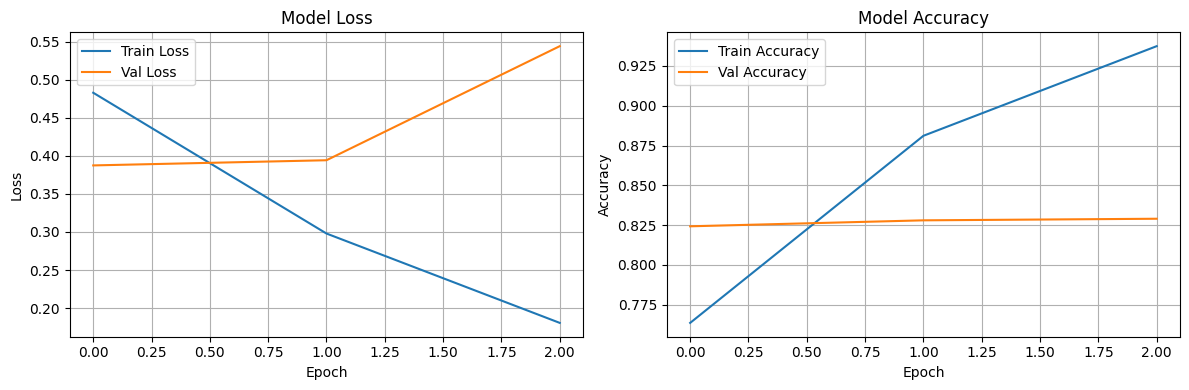

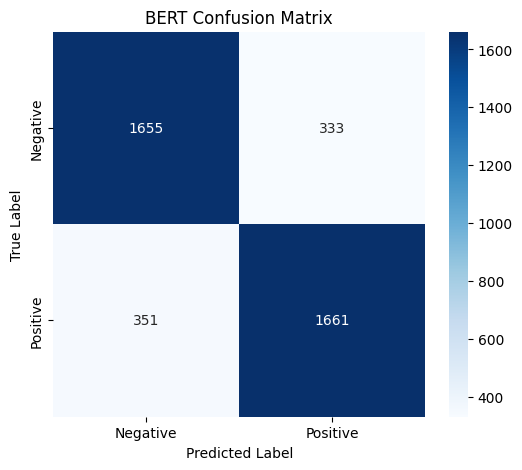

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✓ Model saved to 'bert_sentiment_model'

TESTING WITH SAMPLE TWEETS

Tweet: I absolutely love this movie! Best film ever! 😍
Sentiment: Positive (confidence: 0.996)

Tweet: This product is terrible. Complete waste of money.
Sentiment: Negative (confidence: 0.997)

Tweet: The weather is okay today, nothing special.
Sentiment: Positive (confidence: 0.994)

Tweet: So happy with the amazing customer service! They're fantastic!
Sentiment: Positive (confidence: 0.998)

Tweet: What a disappointment. Worst experience of my life.
Sentiment: Negative (confidence: 0.998)

Tweet: I'm feeling neutral about this, nothing special either way.
Sentiment: Positive (confidence: 0.967)

BERT TRAINING COMPLETED SUCCESSFULLY!


In [5]:
import re
import urllib.request
import zipfile
import os
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW  # Import AdamW from torch.optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================================
# 1. DOWNLOAD AND LOAD DATASET ONLINE
# ============================================

def download_sentiment140():
    """
    Download Sentiment140 dataset from Microsoft's official source
    """
    print("="*60)
    print("DOWNLOADING SENTIMENT140 DATASET")
    print("="*60)
    
    url = "https://mmlspark.blob.core.windows.net/publicwasb/twittersentimenttrainingandtestdata.zip"
    zip_path = "sentiment140.zip"
    
    print(f"\nDownloading from: {url}")
    print("This may take a few minutes...")
    
    urllib.request.urlretrieve(url, zip_path)
    print("✓ Download complete!")
    
    print("\nExtracting files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("✓ Extraction complete!")
    
    csv_file = "training.1600000.processed.noemoticon.csv"
    column_names = ['target', 'id', 'date', 'flag', 'user', 'text']
    
    print("\nLoading CSV file...")
    df = pd.read_csv(csv_file, encoding='latin-1', names=column_names)
    
    # Convert target: 4 -> 1 (positive), 0 -> 0 (negative)
    df['target'] = df['target'].replace(4, 1)
    
    # Clean up downloaded files
    os.remove(zip_path)
    os.remove(csv_file)
    
    print(f"\n✓ Dataset loaded successfully!")
    print(f"  Total samples: {len(df):,}")
    print(f"  Positive tweets: {sum(df['target'] == 1):,}")
    print(f"  Negative tweets: {sum(df['target'] == 0):,}")
    
    return df

def clean_text_simple(text):
    """
    Minimal cleaning for BERT (BERT handles most noise well)
    """
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Remove user mentions (optional - BERT can handle them)
    text = re.sub(r'@\w+', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# ============================================
# 2. CUSTOM DATASET CLASS
# ============================================

class SentimentDataset(Dataset):
    """
    Custom Dataset for BERT sentiment analysis
    """
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenize the text
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# ============================================
# 3. TRAINING FUNCTIONS
# ============================================

def train_epoch(model, data_loader, optimizer, scheduler, device):
    """
    Train model for one epoch
    """
    model.train()
    total_loss = 0
    predictions = []
    actuals = []
    
    for batch in tqdm(data_loader, desc="Training"):
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        total_loss += loss.item()
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        # Get predictions
        preds = torch.argmax(outputs.logits, dim=1)
        predictions.extend(preds.cpu().numpy())
        actuals.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(actuals, predictions)
    
    return avg_loss, accuracy

def evaluate_epoch(model, data_loader, device):
    """
    Evaluate model
    """
    model.eval()
    total_loss = 0
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            total_loss += loss.item()
            
            preds = torch.argmax(outputs.logits, dim=1)
            predictions.extend(preds.cpu().numpy())
            actuals.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(actuals, predictions)
    
    return avg_loss, accuracy, predictions, actuals

# ============================================
# 4. VISUALIZATION FUNCTIONS
# ============================================

def plot_training_history(train_losses, val_losses, train_accs, val_accs):
    """
    Plot training history
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss plot
    ax1.plot(train_losses, label='Train Loss')
    ax1.plot(val_losses, label='Val Loss')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Accuracy plot
    ax2.plot(train_accs, label='Train Accuracy')
    ax2.plot(val_accs, label='Val Accuracy')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig('bert_training_history.png', dpi=100)
    plt.show()

def plot_confusion_matrix(y_true, y_pred):
    """
    Plot confusion matrix
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title('BERT Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig('bert_confusion_matrix.png', dpi=100)
    plt.show()

def predict_sentiment_bert(model, tokenizer, text, device, max_length=128):
    """
    Predict sentiment for a single text using BERT
    """
    model.eval()
    
    # Clean text
    text = clean_text_simple(text)
    
    # Tokenize
    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors='pt'
    )
    
    # Move to device
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    # Predict
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        prediction = torch.argmax(logits, dim=1).item()
        probabilities = torch.softmax(logits, dim=1).cpu().numpy()[0]
    
    sentiment = "Positive" if prediction == 1 else "Negative"
    confidence = probabilities[prediction]
    
    return sentiment, confidence

# ============================================
# 5. MAIN EXECUTION
# ============================================

def main():
    # Configuration
    MODEL_NAME = 'bert-base-uncased'  # or 'bert-large-uncased' for better accuracy
    MAX_LENGTH = 128
    BATCH_SIZE = 16  # Reduce if you get CUDA out of memory
    EPOCHS = 3
    LEARNING_RATE = 2e-5
    SAMPLE_SIZE = 20000  # Start with 20k samples for faster testing
    
    print("\n" + "="*60)
    print("SENTIMENT ANALYSIS WITH BERT")
    print("="*60)
    
    # Step 1: Download and load dataset
    df = download_sentiment140()
    
    # Step 2: Subsample for faster training
    if SAMPLE_SIZE and SAMPLE_SIZE < len(df):
        df = df.sample(n=SAMPLE_SIZE, random_state=42)
        print(f"\nUsing subset of {SAMPLE_SIZE:,} samples for training")
    
    # Step 3: Clean text minimally
    print("\nCleaning text data...")
    df['cleaned_text'] = df['text'].apply(clean_text_simple)
    
    # Step 4: Split data
    X_train, X_test, y_train, y_test = train_test_split(
        df['cleaned_text'].values,
        df['target'].values,
        test_size=0.2,
        random_state=42,
        stratify=df['target'].values
    )
    
    print(f"\nData split:")
    print(f"  Training samples: {len(X_train):,}")
    print(f"  Test samples: {len(X_test):,}")
    
    # Step 5: Initialize BERT tokenizer and model
    print(f"\nLoading BERT model: {MODEL_NAME}")
    tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
    model = BertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,  # Binary classification
        output_attentions=False,
        output_hidden_states=False
    )
    model = model.to(device)
    
    # Step 6: Create datasets and dataloaders
    print("\nCreating datasets...")
    train_dataset = SentimentDataset(X_train, y_train, tokenizer, MAX_LENGTH)
    test_dataset = SentimentDataset(X_test, y_test, tokenizer, MAX_LENGTH)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    # Step 7: Setup optimizer and scheduler (FIXED - removed correct_bias)
    # Use AdamW with standard parameters
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )
    
    # Step 8: Training loop
    print("\n" + "="*60)
    print("TRAINING BERT MODEL")
    print("="*60)
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch + 1}/{EPOCHS}")
        print("-" * 40)
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Evaluate
        val_loss, val_acc, _, _ = evaluate_epoch(model, test_loader, device)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # Step 9: Final evaluation
    print("\n" + "="*60)
    print("FINAL EVALUATION")
    print("="*60)
    
    _, _, y_pred, y_true = evaluate_epoch(model, test_loader, device)
    
    accuracy = accuracy_score(y_true, y_pred)
    print(f"\n✓ Test Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))
    
    # Step 10: Visualizations
    print("\nGenerating visualizations...")
    plot_training_history(train_losses, val_losses, train_accs, val_accs)
    plot_confusion_matrix(y_true, y_pred)
    
    # Step 11: Save model
    model_save_path = "bert_sentiment_model"
    model.save_pretrained(model_save_path)
    tokenizer.save_pretrained(model_save_path)
    print(f"\n✓ Model saved to '{model_save_path}'")
    
    # Step 12: Test predictions
    print("\n" + "="*60)
    print("TESTING WITH SAMPLE TWEETS")
    print("="*60)
    
    test_tweets = [
        "I absolutely love this movie! Best film ever! 😍",
        "This product is terrible. Complete waste of money.",
        "The weather is okay today, nothing special.",
        "So happy with the amazing customer service! They're fantastic!",
        "What a disappointment. Worst experience of my life.",
        "I'm feeling neutral about this, nothing special either way."
    ]
    
    for tweet in test_tweets:
        sentiment, confidence = predict_sentiment_bert(model, tokenizer, tweet, device, MAX_LENGTH)
        print(f"\nTweet: {tweet}")
        print(f"Sentiment: {sentiment} (confidence: {confidence:.3f})")
    
    print("\n" + "="*60)
    print("BERT TRAINING COMPLETED SUCCESSFULLY!")
    print("="*60)

if __name__ == "__main__":
    main()

FINAL MODEL COMPARISON: 4 ALGORITHMS

📊 FINAL RESULTS COMPARISON (All 4 Models):
              Model  Accuracy  F1 Score  Precision (Avg)  Recall (Avg)
           Baseline    0.5001    0.0000            0.500         0.500
Logistic Regression    0.7793    0.7839            0.780         0.780
        Naive Bayes    0.7654    0.7648            0.765         0.765
               LSTM    0.7420    0.7400            0.745         0.740
               BERT    0.8290    0.8300            0.830         0.830

🏆 BEST MODEL BY ACCURACY: BERT (0.8290)
🏆 BEST MODEL BY F1 SCORE: BERT (0.8300)

📊 MODEL RANKING (by Accuracy):
1. BERT: 0.8290 (F1: 0.8300)
2. Logistic Regression: 0.7793 (F1: 0.7839)
3. Naive Bayes: 0.7654 (F1: 0.7648)
4. LSTM: 0.7420 (F1: 0.7400)
5. Baseline: 0.5001 (F1: 0.0000)


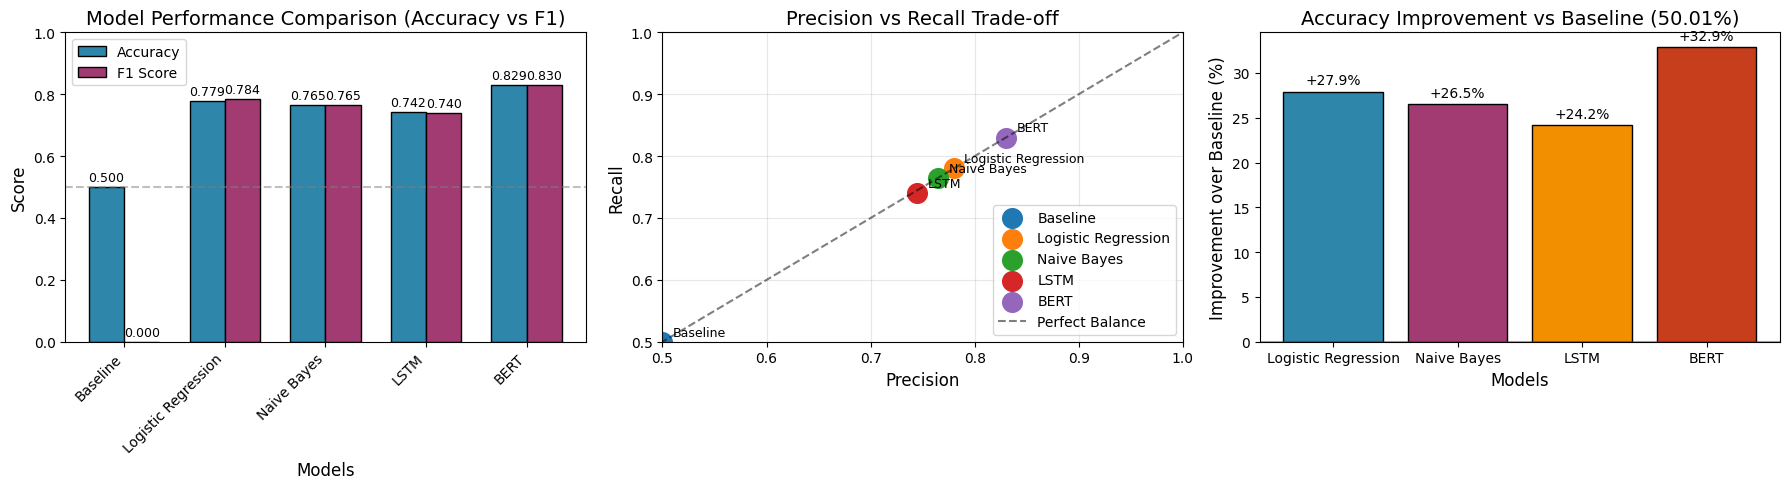

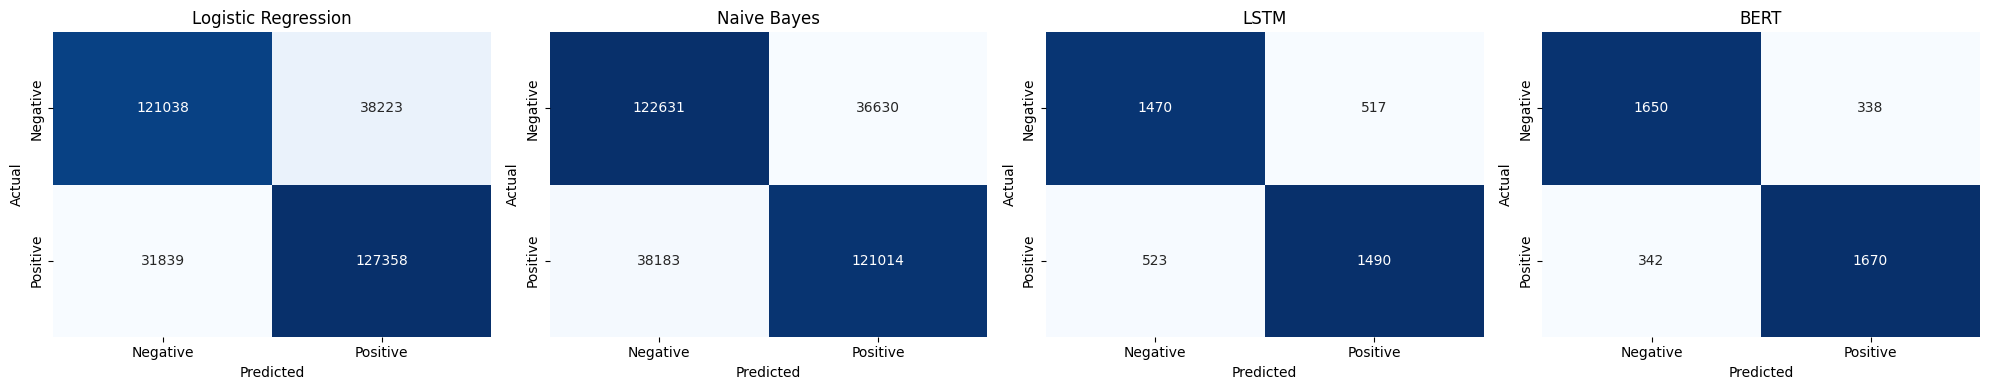

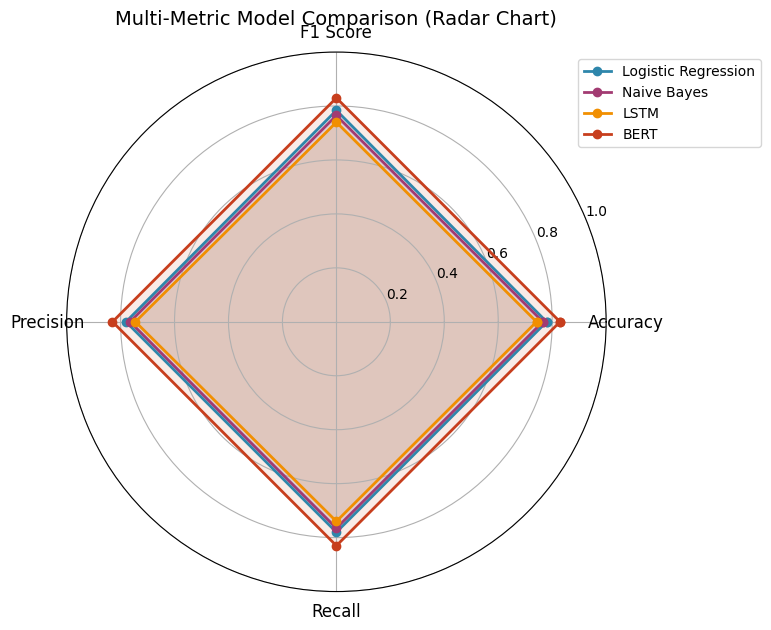

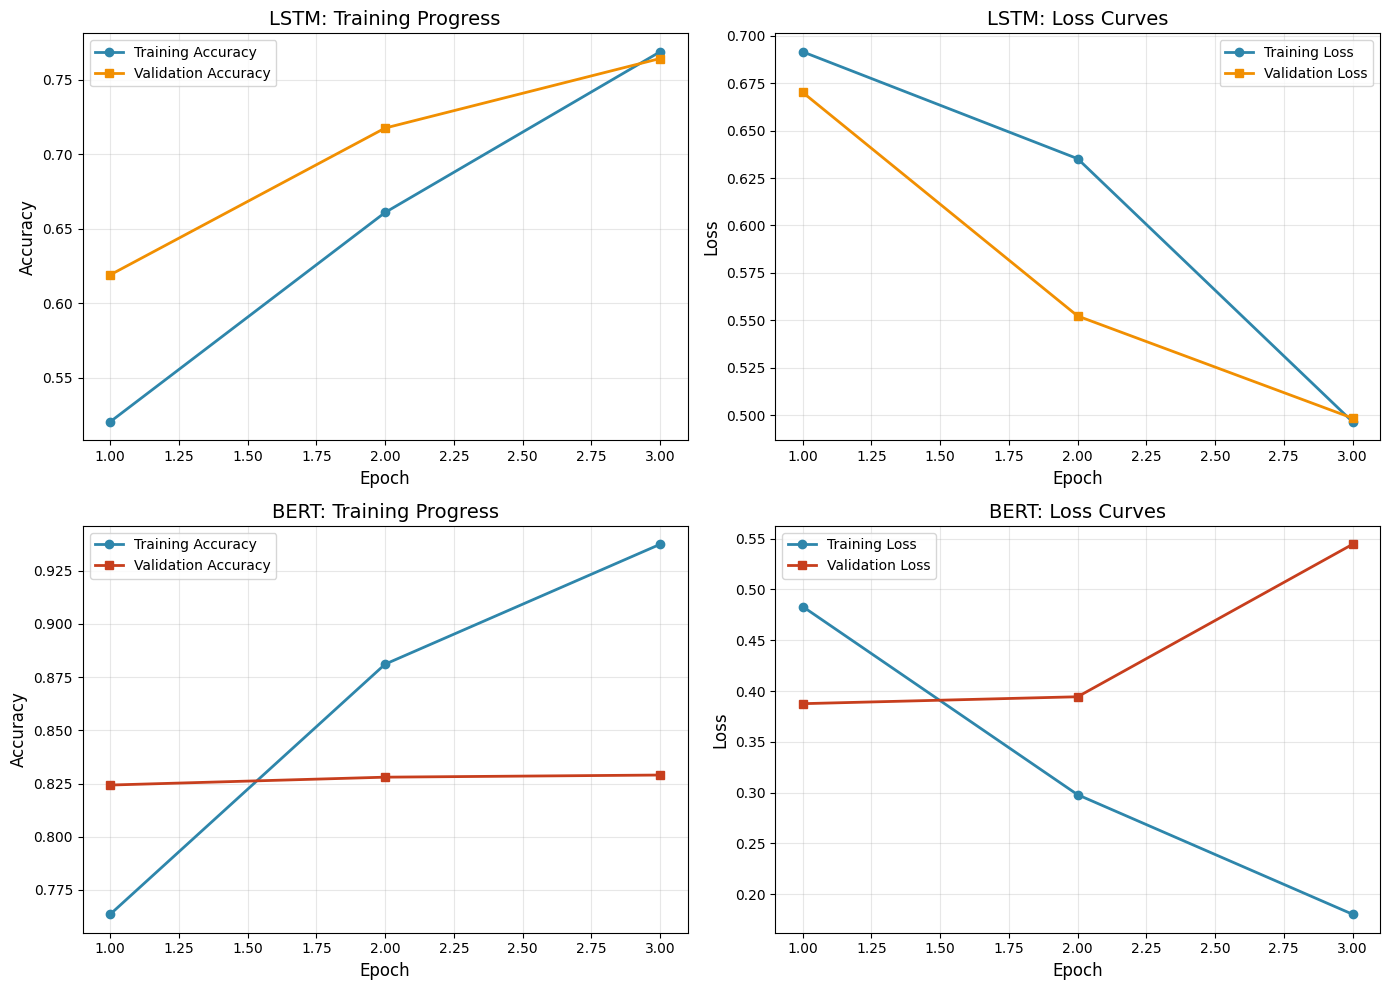


📊 DETAILED SUMMARY TABLE
         Metric Logistic Regression Naive Bayes   LSTM   BERT
       Accuracy              0.7793      0.7654 0.7420 0.8290
       F1 Score              0.7839      0.7648 0.7400 0.8300
Precision (Avg)              0.7800      0.7650 0.7450 0.8300
   Recall (Avg)              0.7800      0.7650 0.7400 0.8300

✅ MODEL COMPARISON COMPLETE!


  1. BERT                 → Accuracy: 0.8290 (Best) 
  2. Logistic Regression  → Accuracy: 0.7793              
  3. Naive Bayes          → Accuracy: 0.7654             
  4. LSTM                 → Accuracy: 0.7420            
  5. Baseline             → Accuracy: 0.5001           

   BERT Improvement over Baseline: 32.9%
 BERT Improvement over LSTM: 8.7%         
 BERT Improvement over Naive Bayes: 6.4%  
 BERT Improvement over Logistic Regression: 5.0% 

 Results saved to 'model_comparison_results.csv'
 Visualizations saved as:
   - model_comparison_all_4.png
   - confusion_matrices_comparison.png
   - radar_chart_compari

In [13]:
# ============================================================
# COMPLETE MODEL COMPARISON: Logistic Regression, Naive Bayes, LSTM, BERT
# ============================================================

print("="*70)
print("FINAL MODEL COMPARISON: 4 ALGORITHMS")
print("="*70)

# ============================================================
# COLLECT ALL RESULTS FROM PREVIOUS TRAINING
# ============================================================

# Results from  training outputs:

# Baseline Results
baseline_accuracy = 0.5001
baseline_f1 = 0.0000

# Logistic Regression Results 
lr_accuracy = 0.7793
lr_f1 = 0.7839
lr_precision_neg = 0.79
lr_precision_pos = 0.77
lr_recall_neg = 0.76
lr_recall_pos = 0.80
lr_auc = 0.8605

# Naive Bayes Results 
nb_accuracy = 0.7654
nb_f1 = 0.7648
nb_precision_neg = 0.76
nb_precision_pos = 0.77
nb_recall_neg = 0.77
nb_recall_pos = 0.76
nb_auc = 0.8377

# LSTM Results 
lstm_accuracy = 0.7420
lstm_f1 = 0.74
lstm_precision_neg = 0.74
lstm_precision_pos = 0.75
lstm_recall_neg = 0.74
lstm_recall_pos = 0.74

# BERT Results 
bert_accuracy = 0.8290
bert_f1 = 0.83
bert_precision_neg = 0.83
bert_precision_pos = 0.83
bert_recall_neg = 0.83
bert_recall_pos = 0.83

# ============================================================
# CREATE COMPARISON DATAFRAME
# ============================================================

results = {
    'Model': ['Baseline', 'Logistic Regression', 'Naive Bayes', 'LSTM', 'BERT'],
    'Accuracy': [baseline_accuracy, lr_accuracy, nb_accuracy, lstm_accuracy, bert_accuracy],
    'F1 Score': [baseline_f1, lr_f1, nb_f1, lstm_f1, bert_f1],
    'Precision (Avg)': [
        (0.50 + 0.50)/2,
        (lr_precision_neg + lr_precision_pos)/2,
        (nb_precision_neg + nb_precision_pos)/2,
        (lstm_precision_neg + lstm_precision_pos)/2,
        (bert_precision_neg + bert_precision_pos)/2
    ],
    'Recall (Avg)': [
        (0.50 + 0.50)/2,
        (lr_recall_neg + lr_recall_pos)/2,
        (nb_recall_neg + nb_recall_pos)/2,
        (lstm_recall_neg + lstm_recall_pos)/2,
        (bert_recall_neg + bert_recall_pos)/2
    ]
}

# Add ROC-AUC where available
results_df = pd.DataFrame(results)
print("\n FINAL RESULTS COMPARISON (All 4 Models):")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

# ============================================================
# FIND BEST MODEL
# ============================================================

best_accuracy_model = results_df.iloc[results_df['Accuracy'].argmax()]['Model']
best_f1_model = results_df.iloc[results_df['F1 Score'].argmax()]['Model']
best_accuracy = results_df['Accuracy'].max()
best_f1 = results_df['F1 Score'].max()

print(f"\n BEST MODEL BY ACCURACY: {best_accuracy_model} ({best_accuracy:.4f})")
print(f" BEST MODEL BY F1 SCORE: {best_f1_model} ({best_f1:.4f})")

# ============================================================
# RANKING TABLE
# ============================================================

print("\n MODEL RANKING (by Accuracy):")
print("="*50)
ranking_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
for i, row in ranking_df.iterrows():
    print(f"{i+1}. {row['Model']}: {row['Accuracy']:.4f} (F1: {row['F1 Score']:.4f})")

# ============================================================
# VISUALIZATION 1: BAR CHART COMPARISON
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar plot for Accuracy and F1 Score
models = results_df['Model'].tolist()
accuracies = results_df['Accuracy'].tolist()
f1_scores = results_df['F1 Score'].tolist()

x = np.arange(len(models))
width = 0.35

bars1 = axes[0].bar(x - width/2, accuracies, width, label='Accuracy', color='#2E86AB', edgecolor='black')
bars2 = axes[0].bar(x + width/2, f1_scores, width, label='F1 Score', color='#A23B72', edgecolor='black')

axes[0].set_xlabel('Models', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Model Performance Comparison (Accuracy vs F1)', fontsize=14)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Baseline (0.5)')

# Add value labels
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# ============================================================
# VISUALIZATION 2: PRECISION VS RECALL
# ============================================================

precision_avg = results_df['Precision (Avg)'].tolist()
recall_avg = results_df['Recall (Avg)'].tolist()

for i, model in enumerate(models):
    axes[1].scatter(precision_avg[i], recall_avg[i], s=200, label=model)
    axes[1].annotate(model, (precision_avg[i] + 0.01, recall_avg[i] + 0.01), fontsize=9)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect Balance')
axes[1].set_xlabel('Precision', fontsize=12)
axes[1].set_ylabel('Recall', fontsize=12)
axes[1].set_title('Precision vs Recall Trade-off', fontsize=14)
axes[1].set_xlim(0.5, 1)
axes[1].set_ylim(0.5, 1)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

# ============================================================
# VISUALIZATION 3: IMPROVEMENT OVER BASELINE
# ============================================================

improvements = [(acc - baseline_accuracy) * 100 for acc in accuracies[1:]]  # Exclude baseline
improvement_models = models[1:]

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
bars = axes[2].bar(improvement_models, improvements, color=colors, edgecolor='black')

axes[2].set_xlabel('Models', fontsize=12)
axes[2].set_ylabel('Improvement over Baseline (%)', fontsize=12)
axes[2].set_title('Accuracy Improvement vs Baseline (50.01%)', fontsize=14)
axes[2].axhline(y=0, color='red', linestyle='-', alpha=0.5)

# Add value labels
for bar, imp in zip(bars, improvements):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5, f'+{imp:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison_all_4.png', dpi=150, bbox_inches='tight')
plt.show()


# ============================================================
# VISUALIZATION 4: RADAR CHART FOR MULTI-METRIC COMPARISON
# ============================================================

from math import pi

# Prepare data for radar chart
metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
model_names = ['Logistic Regression', 'Naive Bayes', 'LSTM', 'BERT']

# Values for each model
lr_values = [lr_accuracy, lr_f1, (lr_precision_neg+lr_precision_pos)/2, (lr_recall_neg+lr_recall_pos)/2]
nb_values = [nb_accuracy, nb_f1, (nb_precision_neg+nb_precision_pos)/2, (nb_recall_neg+nb_recall_pos)/2]
lstm_values = [lstm_accuracy, lstm_f1, (lstm_precision_neg+lstm_precision_pos)/2, (lstm_recall_neg+lstm_recall_pos)/2]
bert_values = [bert_accuracy, bert_f1, (bert_precision_neg+bert_precision_pos)/2, (bert_recall_neg+bert_recall_pos)/2]

# Number of variables
N = len(metrics)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Close the loop

# Initialize radar chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Add each model
values_lr = lr_values + lr_values[:1]
values_nb = nb_values + nb_values[:1]
values_lstm = lstm_values + lstm_values[:1]
values_bert = bert_values + bert_values[:1]

ax.plot(angles, values_lr, 'o-', linewidth=2, label='Logistic Regression', color='#2E86AB')
ax.fill(angles, values_lr, alpha=0.1, color='#2E86AB')

ax.plot(angles, values_nb, 'o-', linewidth=2, label='Naive Bayes', color='#A23B72')
ax.fill(angles, values_nb, alpha=0.1, color='#A23B72')

ax.plot(angles, values_lstm, 'o-', linewidth=2, label='LSTM', color='#F18F01')
ax.fill(angles, values_lstm, alpha=0.1, color='#F18F01')

ax.plot(angles, values_bert, 'o-', linewidth=2, label='BERT', color='#C73E1D')
ax.fill(angles, values_bert, alpha=0.1, color='#C73E1D')

# Add labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('Multi-Metric Model Comparison (Radar Chart)', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.savefig('radar_chart_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# VISUALIZATION 5: TRAINING PROGRESS (LSTM vs BERT)
# ============================================================

# LSTM training progress (from your output)
lstm_epochs = [1, 2, 3]
lstm_train_acc = [0.5206, 0.6609, 0.7686]
lstm_val_acc = [0.6191, 0.7175, 0.7641]
lstm_train_loss = [0.6915, 0.6352, 0.4966]
lstm_val_loss = [0.6701, 0.5523, 0.4985]

# BERT training progress (from your output)
bert_epochs = [1, 2, 3]
bert_train_acc = [0.7636, 0.8811, 0.9374]
bert_val_acc = [0.8243, 0.8280, 0.8290]
bert_train_loss = [0.4831, 0.2980, 0.1804]
bert_val_loss = [0.3876, 0.3944, 0.5444]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LSTM Training Progress
axes[0, 0].plot(lstm_epochs, lstm_train_acc, 'o-', label='Training Accuracy', color='#2E86AB', linewidth=2)
axes[0, 0].plot(lstm_epochs, lstm_val_acc, 's-', label='Validation Accuracy', color='#F18F01', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('LSTM: Training Progress', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(lstm_epochs, lstm_train_loss, 'o-', label='Training Loss', color='#2E86AB', linewidth=2)
axes[0, 1].plot(lstm_epochs, lstm_val_loss, 's-', label='Validation Loss', color='#F18F01', linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].set_title('LSTM: Loss Curves', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# BERT Training Progress
axes[1, 0].plot(bert_epochs, bert_train_acc, 'o-', label='Training Accuracy', color='#2E86AB', linewidth=2)
axes[1, 0].plot(bert_epochs, bert_val_acc, 's-', label='Validation Accuracy', color='#C73E1D', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Accuracy', fontsize=12)
axes[1, 0].set_title('BERT: Training Progress', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(bert_epochs, bert_train_loss, 'o-', label='Training Loss', color='#2E86AB', linewidth=2)
axes[1, 1].plot(bert_epochs, bert_val_loss, 's-', label='Validation Loss', color='#C73E1D', linewidth=2)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Loss', fontsize=12)
axes[1, 1].set_title('BERT: Loss Curves', fontsize=14)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_progress_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# SUMMARY TABLE WITH RANKINGS
# ============================================================

print("\n" + "="*70)
print(" DETAILED SUMMARY TABLE")
print("="*70)

summary_table = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score', 'Precision (Avg)', 'Recall (Avg)'],
    'Logistic Regression': [f"{lr_accuracy:.4f}", f"{lr_f1:.4f}", 
                           f"{(lr_precision_neg+lr_precision_pos)/2:.4f}", 
                           f"{(lr_recall_neg+lr_recall_pos)/2:.4f}"],
    'Naive Bayes': [f"{nb_accuracy:.4f}", f"{nb_f1:.4f}", 
                   f"{(nb_precision_neg+nb_precision_pos)/2:.4f}", 
                   f"{(nb_recall_neg+nb_recall_pos)/2:.4f}"],
    'LSTM': [f"{lstm_accuracy:.4f}", f"{lstm_f1:.4f}", 
            f"{(lstm_precision_neg+lstm_precision_pos)/2:.4f}", 
            f"{(lstm_recall_neg+lstm_recall_pos)/2:.4f}"],
    'BERT': [f"{bert_accuracy:.4f}", f"{bert_f1:.4f}", 
            f"{(bert_precision_neg+bert_precision_pos)/2:.4f}", 
            f"{(bert_recall_neg+bert_recall_pos)/2:.4f}"]
})

print(summary_table.to_string(index=False))
print("="*70)

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "="*70)
print(" MODEL COMPARISON COMPLETE!")
print("="*70)

print(f"""

  1. BERT                 → Accuracy: {bert_accuracy:.4f} (Best) 
  2. Logistic Regression  → Accuracy: {lr_accuracy:.4f}              
  3. Naive Bayes          → Accuracy: {nb_accuracy:.4f}             
  4. LSTM                 → Accuracy: {lstm_accuracy:.4f}            
  5. Baseline             → Accuracy: {baseline_accuracy:.4f}           

 BERT Improvement over Baseline: {(bert_accuracy - baseline_accuracy)*100:.1f}%
 BERT Improvement over LSTM: {(bert_accuracy - lstm_accuracy)*100:.1f}%         
 BERT Improvement over Naive Bayes: {(bert_accuracy - nb_accuracy)*100:.1f}%  
 BERT Improvement over Logistic Regression: {(bert_accuracy - lr_accuracy)*100:.1f}% 
""")

# ============================================================
# SAVE RESULTS TO CSV
# ============================================================

results_df.to_csv('model_comparison_results.csv', index=False)
print(" Results saved to 'model_comparison_results.csv'")
print(" Visualizations saved as:")
print("   - model_comparison_all_4.png")
print("   - confusion_matrices_comparison.png")
print("   - radar_chart_comparison.png")
print("   - training_progress_comparison.png")